# AsyncFlow — MM1 Theory vs Simulation (Guided Notebook)

This notebook shows how to:

1. Make imports work inside a notebook (src-layout or package install)
2. Build a **single-server** scenario compatible with **M/M/1** assumptions
3. Run the simulation and collect results
4. Compare theory vs observed KPIs (pretty-printed table)
5. Plot the standard dashboards (latency, throughput, server time series)

> Tip: run this notebook from your project **root folder**.


In [1]:
import sys, importlib

# 1) Svuota tutto ciò che inizia con 'asyncflow' da sys.modules
for m in list(sys.modules):
    if m.startswith("asyncflow"):
        del sys.modules[m]

from asyncflow import AsyncFlow, SimulationRunner
from asyncflow.analysis import MMc, ResultsAnalyzer, SweepAnalyzer
from asyncflow.components import (
    Client, Server, LinkEdge, Endpoint, LoadBalancer, ArrivalsGenerator
)
from asyncflow.settings import SimulationSettings

import simpy

In [ ]:
import matplotlib.pyplot as plt
import simpy

# Public AsyncFlow API
from asyncflow import AsyncFlow, SimulationRunner, Sweep
from asyncflow.components import Client, Server, LinkEdge, Endpoint, ArrivalsGenerator
from asyncflow.settings import SimulationSettings
from asyncflow.analysis import MMc, ResultsAnalyzer, SweepAnalyzer
from asyncflow.enums import Distribution

print("Imports OK.")

ImportError: cannot import name 'Edge' from 'asyncflow.components' (/home/gioele/projects/AsyncFlow/src/asyncflow/components/__init__.py)

## 1) Build an M/M/1-friendly scenario

* **Single server with exponential CPU service**
  One server, one endpoint, exactly **one CPU-bound step** with an **Exponential** service-time RV (mean $E[S]$). No RAM/IO steps in the pipeline.

* **No load balancer**
  Topology has **exactly one server** and **no LB** (no fan-out, no parallelism).

* **Deterministic, very small network latency**
  All edges use a **fixed latency** $\ll 1\,\mathrm{ms}$ so queueing is dominated by CPU service (closer to textbook M/M/1).

* **“Poisson arrivals” via the generator**
 

```mermaid
graph LR;
    rqs1["<b>ArrivalsGenerator</b><br/>id: rqs-1"]
    client1["<b>Client</b><br/>id: client-1"]
    app1["<b>Server</b><br/>id: app-1<br/>Endpoint: /api"]

    rqs1 -- "Edge: gen-client<br/>Latency: 0.0001" --> client1;
    client1 -- "Request<br/>Edge: client-app<br/>Latency: 0.0001" --> app1;
    app1 -- "Response<br/>Edge: app-client<br/>Latency: 0.0001" --> client1;

In [ ]:
def build_payload():
    generator = ArrivalsGenerator(
        id="rqs-1",
        lambda_rps=30,
        model=Distribution.POISSON
    )

    client = Client(id="client-1")

    endpoint = Endpoint(
        endpoint_name="/api",
        probability=1.0,
        steps=[
            {
                "kind": "initial_parsing",  # CPU-bound step
                "step_operation": {
                    "cpu_time": {"mean": 0.015, "distribution": "exponential"},
                },
            },
        ],
    )

    server = Server(
        id="app-1",
        server_resources={"cpu_cores": 1, "ram_mb": 2048},
        endpoints=[endpoint],
    )

    e_gen_client = LinkEdge(id="gen-client", source="rqs-1", target="client-1")
    e_client_app = LinkEdge(id="client-app", source="client-1", target="app-1")
    e_app_client = LinkEdge(id="app-client", source="app-1", target="client-1")

    settings = SimulationSettings(
        total_simulation_time=2400,
        sample_period_s=0.05,
    )

    payload = (
        AsyncFlow()
        .add_arrivals_generator(generator)
        .add_client(client)
        .add_servers(server)
        .add_edges(e_gen_client, e_client_app, e_app_client)
        .add_simulation_settings(settings)
    ).build_payload()
    return payload


## 2) Run the simulation


In [ ]:
payload = build_payload()
env = simpy.Environment()
runner = SimulationRunner(env=env, simulation_input=payload)
results: ResultsAnalyzer = runner.run()
print("Done.")

Done.


## 3) MM1 theory vs observed comparison 
If the payload violates MM1 assumptions, a readable error is shown instead.
## Variables (what they represent)

* **λ (lambda)**: mean **arrival rate**, in requests/second.
* **μ (mu)**: mean **service rate**, in requests/second (= 1 / mean service time).
* **ρ (rho)**: **utilization** of the server, ρ = λ / μ (unitless).
* **W**: **mean time in system** (end-to-end latency, queue + service), in seconds.
* **Wq**: **mean waiting time in queue** (before service), in seconds.
* **L**: **mean number in system** (in queue + in service), unitless.
* **Lq**: **mean number in queue**, unitless.
* **E\[S]**: **mean service time** at the server (CPU only), in seconds.


> In the comparison table you’ll see two columns: **Theory** (closed-form M/M/1 values) and **Observed** (estimates from the run). The run is a single execution; “Theory” is the model prediction, “Observed” is what was measured.

---

## How we compute the **Theory** column (M/M/1)

1. **Predicted arrival rate**

$$
\lambda_{\text{Theory}} \;=\; 
\ input data
$$

2. **Predicted service rate** (from the **CPU exponential step** with mean $E[S]$)

$$
\mu_{\text{Theory}} \;=\; \frac{1}{E[S]}
$$

3. **M/M/1 closed forms** (valid when $\lambda_{\text{Theory}} < \mu_{\text{Theory}}$)

$$
\begin{aligned}
\rho_{\text{Theory}} &= \frac{\lambda_{\text{Theory}}}{\mu_{\text{Theory}}} \\
W_{\text{Theory}}    &= \frac{1}{\mu_{\text{Theory}} - \lambda_{\text{Theory}}} \\
W_{q,\text{Theory}}  &= \frac{\rho_{\text{Theory}}}{\mu_{\text{Theory}} - \lambda_{\text{Theory}}} \\
L_{\text{Theory}}    &= \lambda_{\text{Theory}}\, W_{\text{Theory}} \;=\; \frac{\rho_{\text{Theory}}}{1-\rho_{\text{Theory}}} \\
L_{q,\text{Theory}}  &= \lambda_{\text{Theory}}\, W_{q,\text{Theory}} \;=\; \frac{\rho_{\text{Theory}}^{2}}{1-\rho_{\text{Theory}}}
\end{aligned}
$$

If $\lambda_{\text{Theory}} \ge \mu_{\text{Theory}}$, the system is **unstable** and $W, W_q, L, L_q$ **diverge** (we display them as $+\infty$).

---

## How we compute the **Observed** column (from the run)

After the `ResultsAnalyzer` processes metrics:

1. **Observed arrival rate** (mean throughput across time windows)

$$
\lambda_{\text{Observed}} \;=\; \text{mean}\big(\text{windowed RPS series}\big)
$$

2. **Observed time in system** (client end-to-end latency)

$$
W_{\text{Observed}} \;=\; \text{mean}\big(\text{client latencies}\big)
$$

3. **Observed service rate** (from server service times)

$$
\overline{S}=\text{mean}(\text{service\_time}), 
\qquad
\mu_{\text{Observed}}=
\begin{cases}
1/\overline{S} & \overline{S}>0\\
+\infty & \overline{S}=0
\end{cases}
$$

4. **Observed waiting time in queue** (from server queue wait times)

$$
W_{q,\text{Observed}} \;=\; \text{mean}(\text{waiting\_time})
$$

5. **Little’s law (observed)**

$$
L_{\text{Observed}}=\lambda_{\text{Observed}}\, W_{\text{Observed}},
\qquad
L_{q,\text{Observed}}=\lambda_{\text{Observed}}\, W_{q,\text{Observed}}
$$

6. **Observed utilization**

$$
\rho_{\text{Observed}}=
\begin{cases}
\lambda_{\text{Observed}} / \mu_{\text{Observed}} & \mu_{\text{Observed}} \not\in \{0,+\infty\}\\
0 & \text{otherwise}
\end{cases}
$$

> **Why small deltas appear:** warm-up effects, the user-sampling window (piecewise-constant rate), finite simulation horizon. Increasing the simulation time typically shrinks these deltas.


In [ ]:
mm1 = MMc()
if mm1.is_compatible(payload):
    mm1.print_comparison(payload, results)  
else:
    print("Payload is not compatible with M/M/1:")
    for reason in mm1.explain_incompatibilities(payload):
        print(" -", reason)


MMc (RR) — Theory vs Observed
-----------------------------------------------------------------
sym  metric                   theory   observed        abs   rel%
-----------------------------------------------------------------
λ    Arrival rate (1/s)    30.000000  29.880417  -0.119583  -0.40
μ    Service rate (1/s)    66.666667  66.698879   0.032212   0.05
c    Servers                1.000000   1.000000   0.000000   0.00
rho  Utilization            0.450000   0.447990  -0.002010  -0.45
L    Mean items in sys      0.818182   0.821040   0.002858   0.35
Lq   Mean items in queue    0.368182   0.364086  -0.004096  -1.11
W    Mean time in sys (s)   0.027273   0.027478   0.000205   0.75
Wq   Mean waiting (s)       0.012273   0.012185  -0.000088  -0.72


### 4) Plot dashboards

**System-level and per-server charts**

Beyond the two main panels (latency histogram + throughput time series), AsyncFlow records **rich time series and per-request distributions** that make the system behavior easy to read. In your scenario (single server, exponential CPU only, no I/O/RAM), you’ll see:

* **System dashboard**

  * **Request Latency Distribution**: end-to-end histogram (client→server→client) with **mean, P50, P95, P99** markers. Here latency is dominated by CPU service + short queue; vertical lines highlight tail behavior.
  * **Throughput (RPS)**: windowed time series with **mean, P95, max**. Great for spotting stability, oscillations, and warm-up.

* **Server time-series dashboard (for `app-1`)**

  * **Ready queue length**: CPU queue over time with **mean/min/max**. With ρ≈0.5 the mean queue ≈0.5, consistent with M/M/1.
  * **I/O queue length**: flat at zero (no I/O step in the pipeline).
  * **RAM in use**: flat at zero (no RAM step in the pipeline).

* **Server event-metrics dashboard**

  * **Server-side latency**: histogram of (waiting + service) at the server.
  * **CPU service time**: histogram of **service\_time** (Exp \~15 ms) with P95/P99.
  * **CPU waiting time**: histogram of queue **waiting\_time**; shows the heavy tail under bursts.
  * **I/O time**: flat at zero (no I/O).

#### What you “get for free” from the collected data

* **Distributions** (per-request arrays): end-to-end latency, server latency, **service\_time**, **waiting\_time**, (optional) **io\_time** ⇒ percentiles, variance, pre/post comparisons.
* **Time series** (periodic sampling): **ready\_queue\_len**, **event\_loop\_io\_sleep** (if I/O exists), **ram\_in\_use**, **edge\_concurrent\_connection**, plus **throughput series** to estimate observed λ.
* **Derived checks**: automatic **Little’s Law** sanity (L≈λW, Lq≈λWq), observed utilization **ρ̂ = λ̂/μ̂**, and the **MM1 theory vs observed** comparison table you printed.

> In this specific setup, I/O and RAM panels are flat by design; add I/O or RAM steps and those plots will populate accordingly.


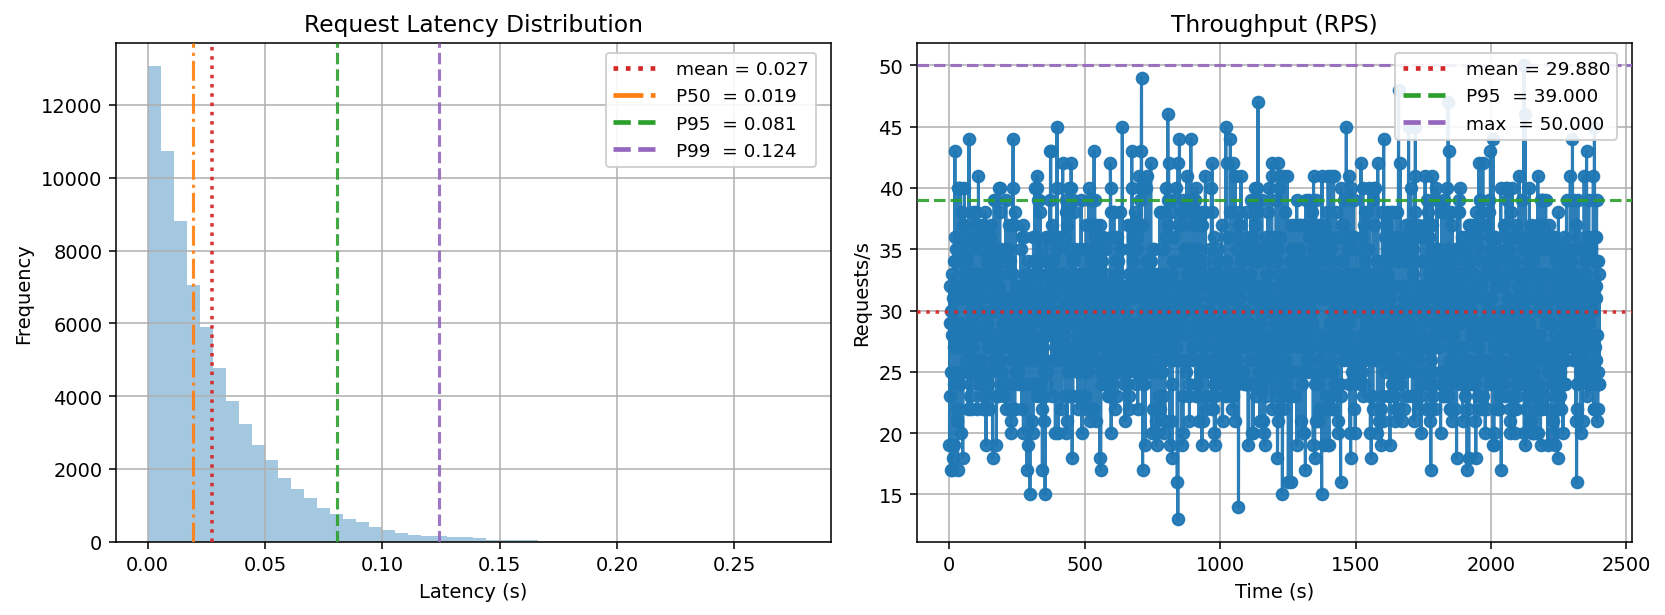

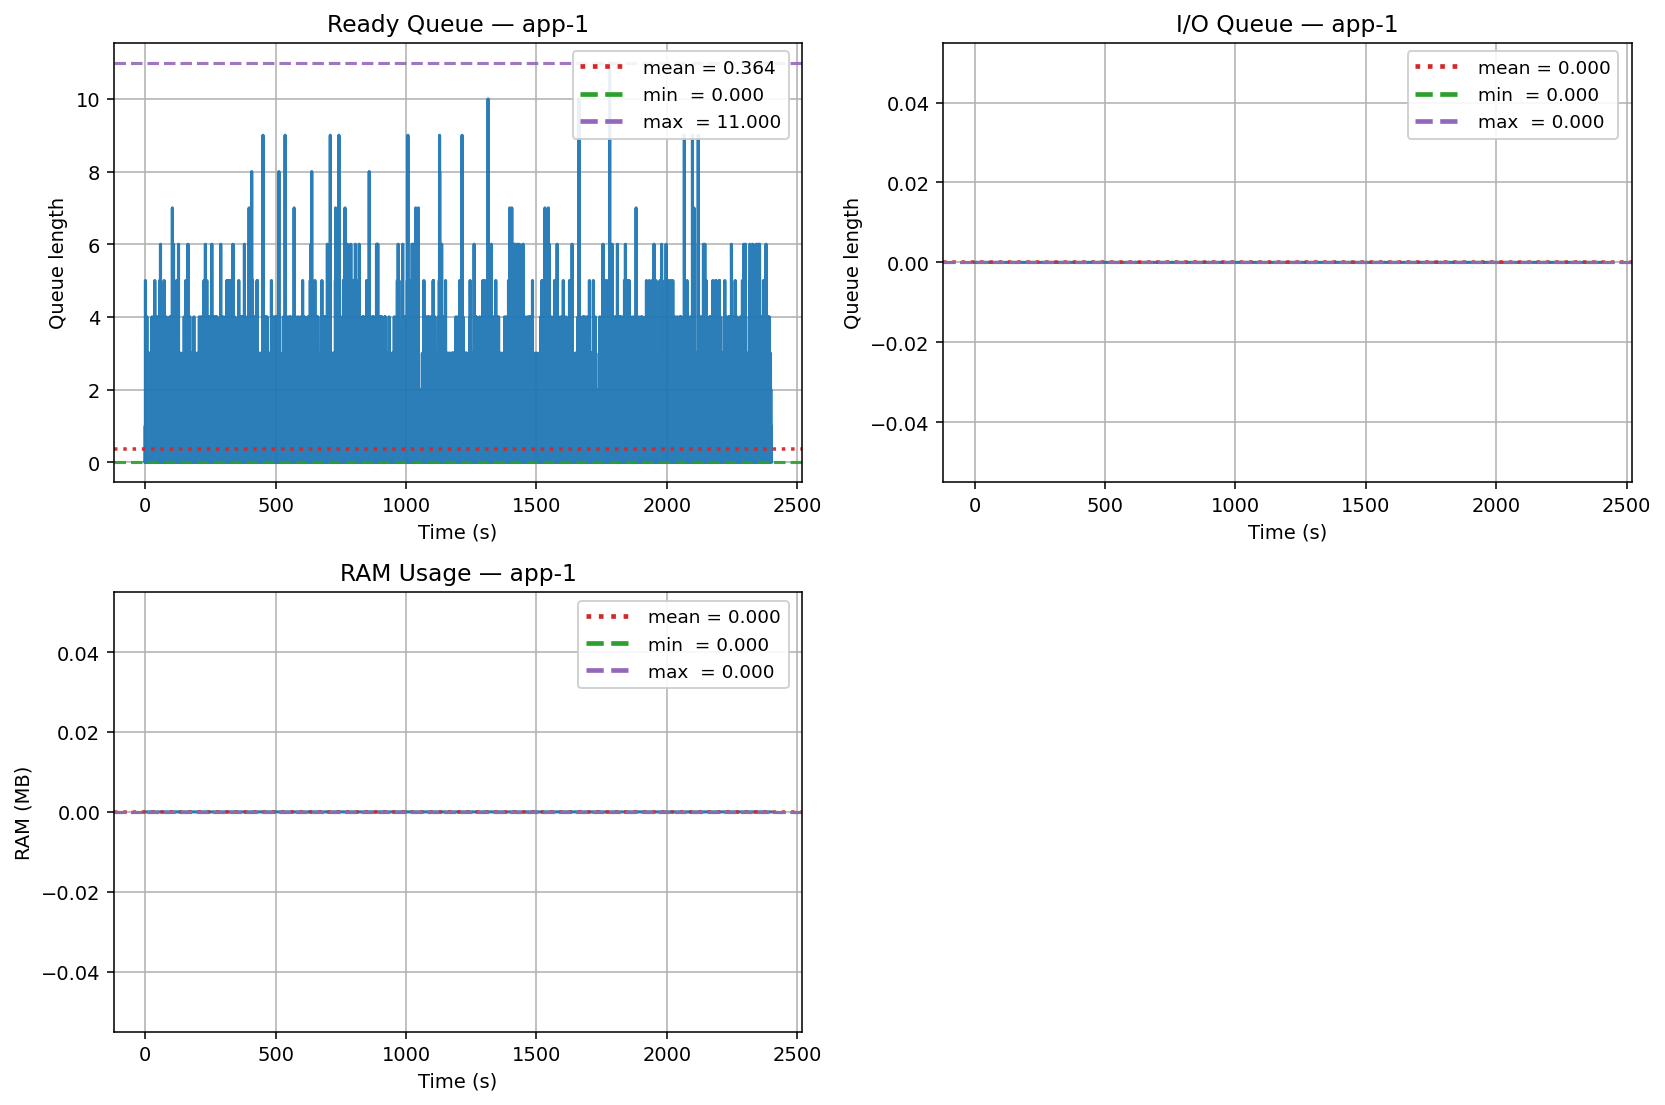

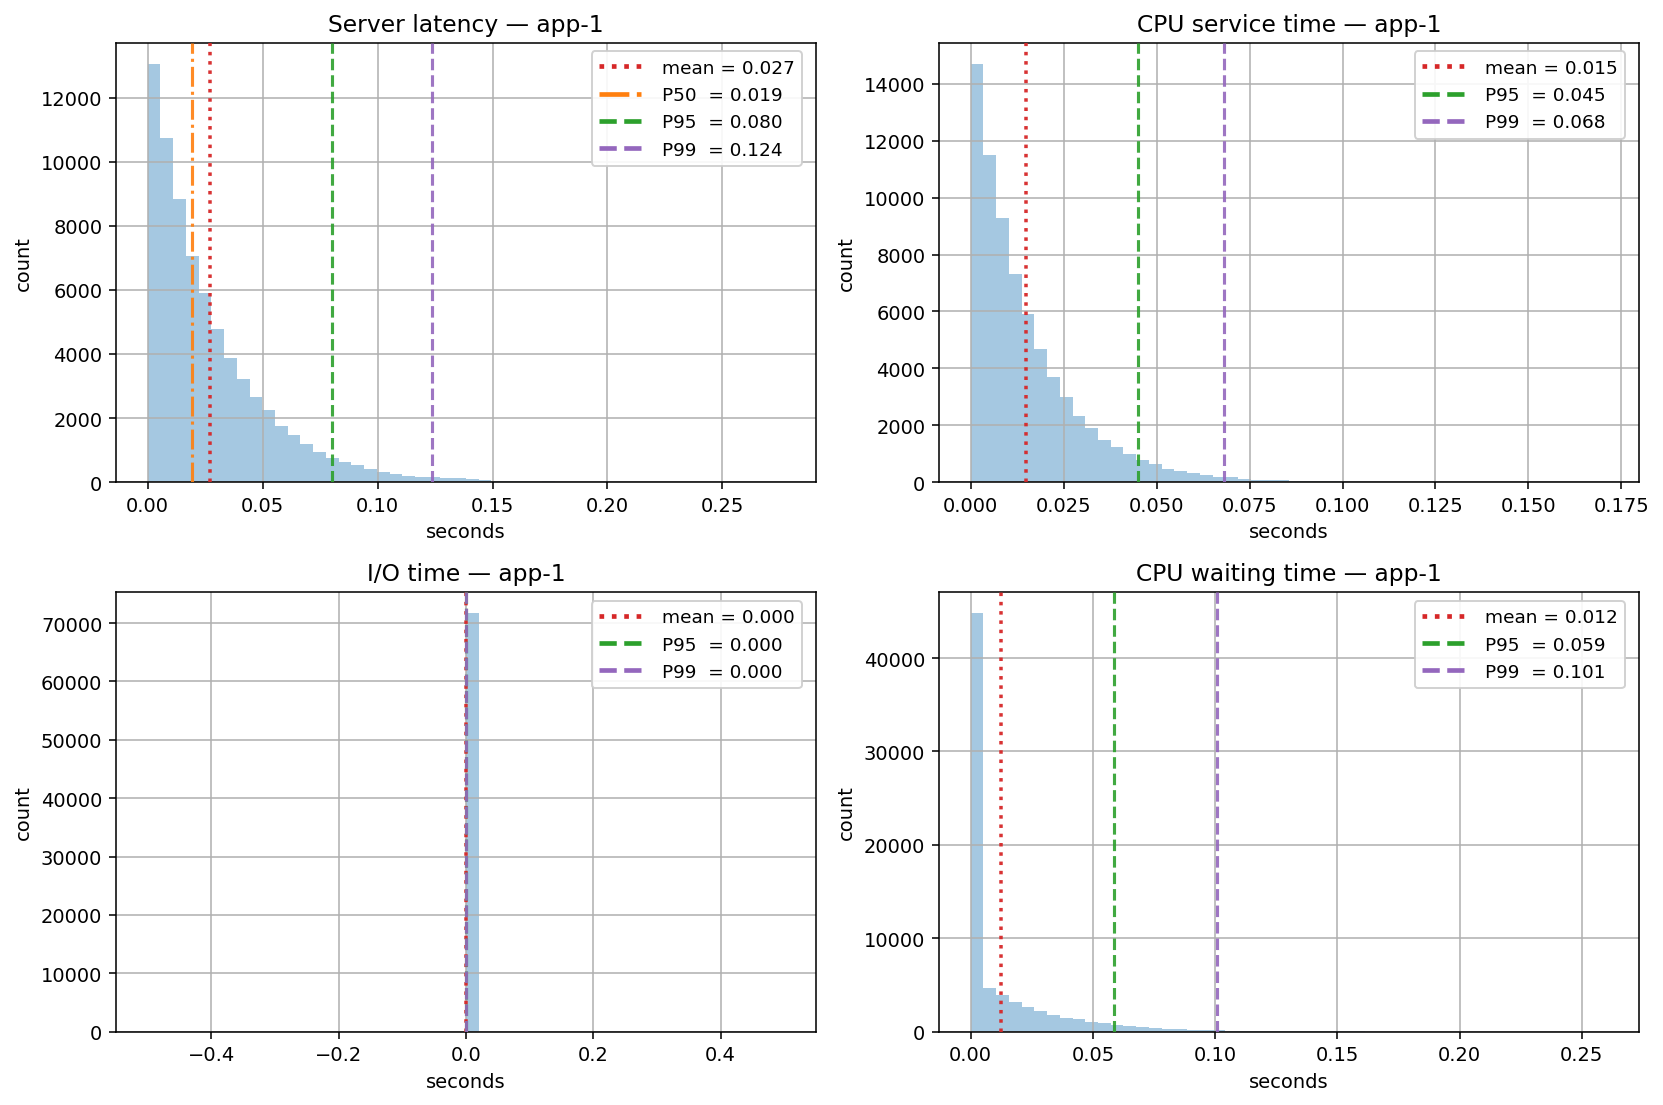

In [ ]:
# 4.1 System dashboard: latency + throughput
fig_sys, axes_sys = plt.subplots(1, 2, figsize=(12, 4.5), dpi=140)
results.plot_latency_distribution(axes_sys[0])
results.plot_throughput(axes_sys[1])
fig_sys.tight_layout()
plt.show()

# 4.2 Server time-series and event-metric dashboards
sids = results.list_server_ids()
if sids:
    sid = sids[0]
    fig_ts, axes_ts = plt.subplots(2, 2, figsize=(12, 8), dpi=140)
    axes_ts[1, 1].axis("off")
    results.plot_server_timeseries_dashboard(
        ax_ready=axes_ts[0, 0],
        ax_io=axes_ts[0, 1],
        ax_ram=axes_ts[1, 0],
        server_id=sid,
    )
    fig_ts.tight_layout()
    plt.show()

    fig_ev, axes_ev = plt.subplots(2, 2, figsize=(12, 8), dpi=140)
    results.plot_server_event_metrics_dashboard(
        ax_latency_hist=axes_ev[0, 0],
        ax_service_hist=axes_ev[0, 1],
        ax_io_hist=axes_ev[1, 0],
        ax_wait_hist=axes_ev[1, 1],
        server_id=sid,
    )
    fig_ev.tight_layout()
    plt.show()
else:
    print("No servers present in the topology.")



## 5) Sweep over mean concurrent users
We iterate the scenario by changing the *mean concurrent users* from 10 to 200 (step 5).
For each grid point we run a fresh simulation and keep the ResultsAnalyzer.
Then we wrap everything in `SweepAnalyzer`, which caches the data for plotting.

In [ ]:
payload_base = build_payload()

sweeper = Sweep()
pairs = sweeper.sweep_on_lambda(
    payload=payload_base,
    lambda_lower_bound=10,
    lambda_upper_bound=100,
    step=5,
)

# Wrap with the sweep analyzer and pre-collect/caches
sweep = SweepAnalyzer(pairs)
sweep.precollect()

print(f"Sweep points: {len(pairs)}")
if pairs:
    print("Server IDs detected:", pairs[0][1].list_server_ids())


Sweep points: 19
Server IDs detected: ['app-1']


## 6) Global plots (system-level)
We plot: 
 - Throughput (mean RPS) vs lambda
 - Mean latency (W) vs lambda
 - latency percentiles vs lambda.


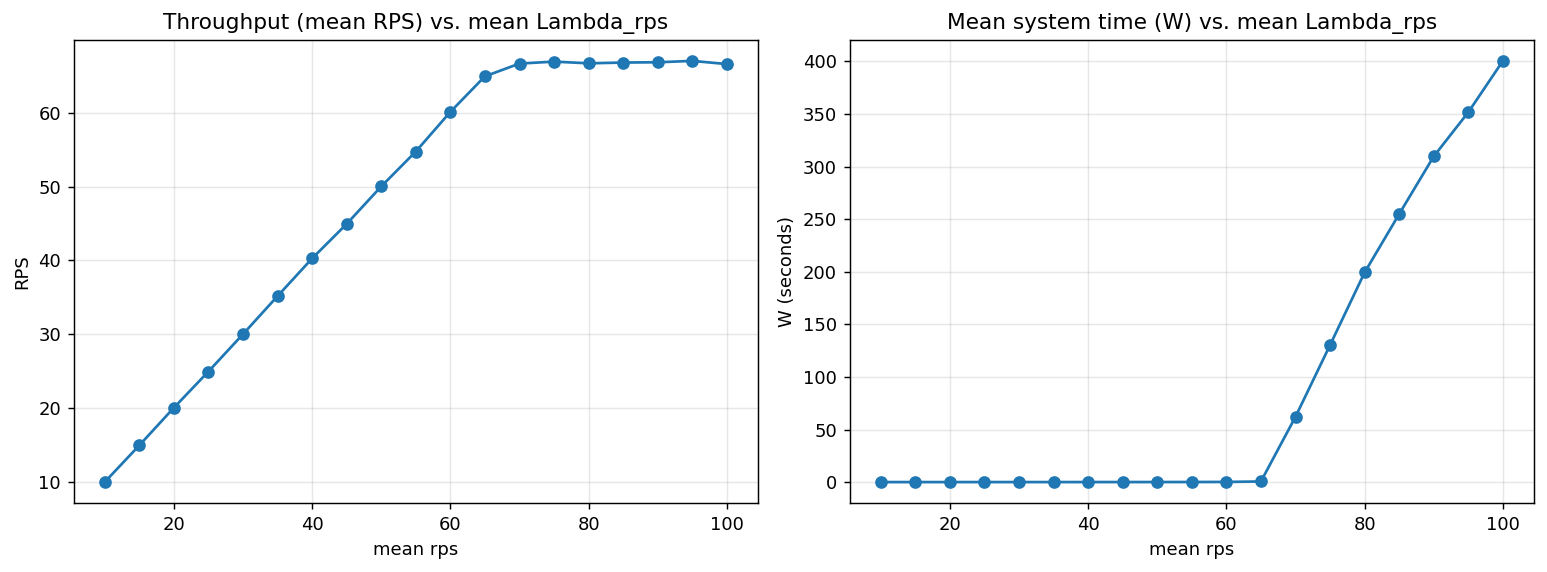

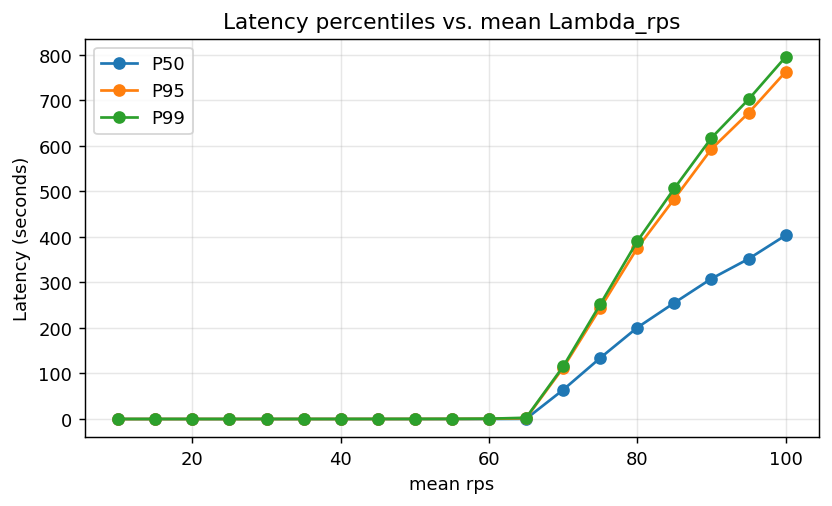

In [ ]:
fig_global = sweep.plot_global_dashboard()
plt.show()

# 6.2  Latency percentiles vs users (P50, P95, P99)
fig_pct, ax_pct = plt.subplots(1, 1, figsize=(6.5, 4.0), dpi=130)
sweep.plot_global_latency_percentiles(ax_pct)
fig_pct.tight_layout()
plt.show()



## 7) Per-server overlays
We plot per-server curves over users (utilization ρ_i, waiting time Wq_i, service rate μ_i, throughput λ_i).
If multiple servers exist, overlays show a line per server.
Below we also show the *single-server* case by explicitly passing the server id.


/tmp/ipykernel_19002/23993299.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


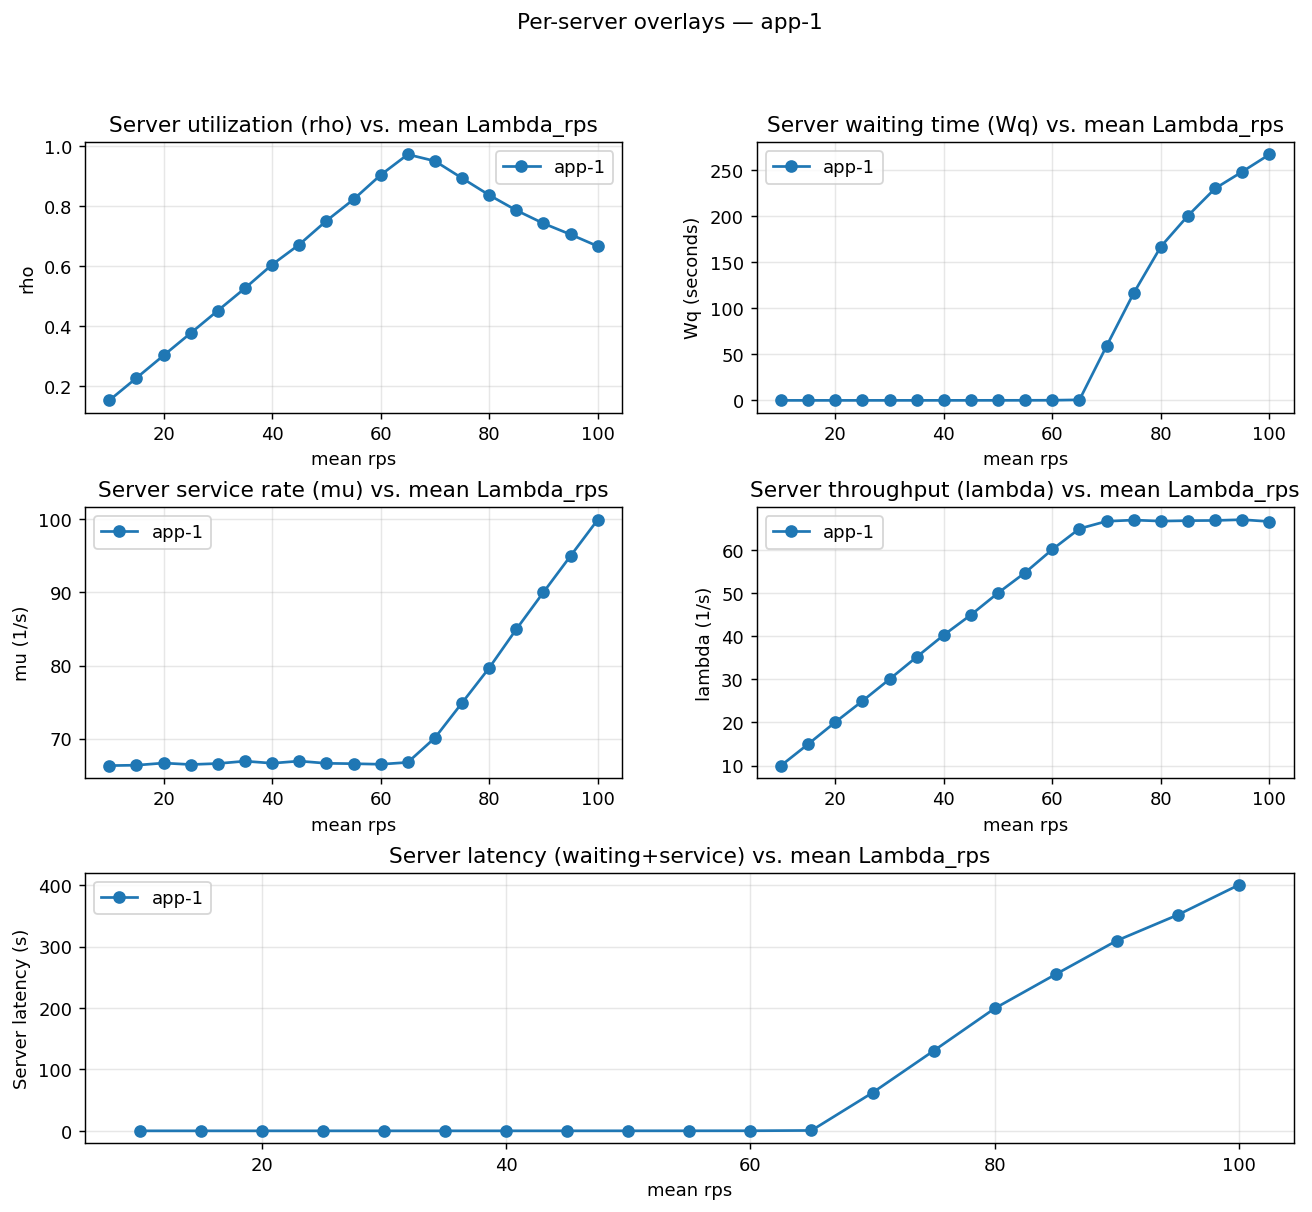

In [ ]:
# 7.1 Single-server overlays (explicit server id), if present
server_ids = pairs[0][1].list_server_ids() if pairs else []
if server_ids:
    sid = server_ids[0]

    fig = plt.figure(figsize=(12, 10), dpi=130)
    gs = fig.add_gridspec(nrows=3, ncols=2, hspace=0.35, wspace=0.25)

    # Row 1 (2 charts)
    ax11 = fig.add_subplot(gs[0, 0])
    ax12 = fig.add_subplot(gs[0, 1])

    # Row 2 (2 charts)
    ax21 = fig.add_subplot(gs[1, 0])
    ax22 = fig.add_subplot(gs[1, 1])

    # Row 3 (1 chart spanning both columns)
    ax3 = fig.add_subplot(gs[2, :])

    # Plots
    sweep.plot_server_utilization_overlay(ax11, server_ids=[sid])
    sweep.plot_server_waiting_time_overlay(ax12, server_ids=[sid])
    sweep.plot_server_service_rate_overlay(ax21, server_ids=[sid])
    sweep.plot_server_throughput_overlay(ax22, server_ids=[sid])
    sweep.plot_server_latency_overlay(ax3, server_ids=[sid])  # full-width

    fig.suptitle(f"Per-server overlays — {sid}", y=0.98)
    fig.tight_layout()
    plt.show()
else:
    print("No servers present — skipping per-server overlays.")
